# 10 — Mixture-of-Experts: Scaling Capacity Without Scaling Compute

Welcome to the **capstone notebook** of the course!

In notebooks 01–09 we went from a bag-of-words model all the way to a fully
trained character-level GPT, explored hyperparameter tuning, and built a BPE
tokenizer from scratch. Now we tackle one of the most important architectural
ideas powering frontier models like Mixtral and GPT-4:
**Mixture-of-Experts (MoE)**.

Here is what you will build and understand:

1. **Expert**: a small feed-forward network (one of many specialists).
2. **Router / gating**: a lightweight linear layer that decides which experts
   each token should visit.
3. **Top-k routing**: each token visits only *k* out of *N* experts — sparse
   computation, but the model has *N* times the feed-forward capacity.
4. **Load-balancing auxiliary loss**: a regulariser that stops the router from
   collapsing to always choosing the same expert.
5. **MoEGPT**: a compact transformer that swaps the standard MLP for an
   `MoEFeedForward` layer in every block.
6. **Active vs total parameters**: why MoE is such an attractive way to scale.

## Working directory

Jupyter runs notebooks from the `notebooks/` folder. The cell below walks up
the directory tree until it finds the project root (marked by
`requirements.txt`) and changes the working directory there, so
`from model import ...` resolves correctly no matter how you launched Jupyter.

In [1]:
import os, sys
while not os.path.exists("requirements.txt"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir(parent)
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())

Working directory: /Users/carlosbarbosa/Documents/GitHub/train-llm


## Imports, device, and seed

In [2]:
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from model import RMSNorm, CausalSelfAttention, build_rope, GPTConfig

torch.manual_seed(42)
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("device:", device)

device: mps


---
## Part 1 — The Big Idea: Sparse Experts

Standard transformers have one big MLP (feed-forward network) per layer.
Every token passes through *the same* MLP every time — simple, but wasteful:
the MLP has to learn to handle *all* kinds of tokens (punctuation, verbs,
numbers, …) with a single set of weights.

**Mixture-of-Experts** replaces that single MLP with `N` smaller ones called
**experts**. A learned **router** (also called a *gate*) looks at each token
and picks the `top_k` most relevant experts for it.

Why is this useful?

| Property | Dense MLP | MoE |
|---|---|---|
| Parameters | 1× | N× |
| Compute per token | 1× | k/N × (only k experts run) |
| Effective capacity | small | large |

This is called **sparse activation**: the model has more total parameters, but
each token only *activates* a fraction of them. The compute cost stays roughly
constant while capacity scales with `N`. That is the core insight behind
Mixtral-8×7B and similar models.

---
## Part 2 — A Single Expert (SwiGLU MLP)

Each expert is just a small SwiGLU feed-forward network — the same activation
function used in Llama / our `model.py`. Nothing special about one expert in
isolation; the magic comes from having many of them and routing between them.

**SwiGLU recap**: uses two parallel projections (`w1`, `w3`) combined with the
SiLU (Sigmoid Linear Unit) activation, then a down-projection (`w2`).
`output = w2( silu(w1(x)) * w3(x) )`. The gating via `w3` lets the network
learn to suppress irrelevant activations.

In [3]:
class Expert(nn.Module):
    """A single SwiGLU expert — identical architecture to the MLP in model.py."""

    def __init__(self, n_embd, dropout=0.0):
        super().__init__()
        # Hidden dimension rounded up to the nearest multiple of 64 (clean memory layout).
        hidden = 64 * (((int(8 / 3 * n_embd)) + 63) // 64)
        self.w1 = nn.Linear(n_embd, hidden, bias=False)   # gate projection
        self.w3 = nn.Linear(n_embd, hidden, bias=False)   # up projection
        self.w2 = nn.Linear(hidden, n_embd, bias=False)   # down projection
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # SwiGLU: silu(gate) * up, then project back down.
        return self.dropout(self.w2(F.silu(self.w1(x)) * self.w3(x)))


# Quick sanity check on one expert.
_e = Expert(64)
_out = _e(torch.randn(5, 64))
print("Expert output shape:", _out.shape)   # should be (5, 64)
assert _out.shape == (5, 64)

Expert output shape: torch.Size([5, 64])


---
## Part 3 — MoEFeedForward: Top-k Routing + Load-Balancing Aux Loss

This is the heart of the notebook. Let's walk through it step by step.

### 3a. The gate
A single linear layer maps each token embedding to `n_experts` logits.
Softmax turns those into probabilities — that is the **router** or **gating
network**.

### 3b. Top-k selection
We keep only the `top_k` experts with the highest probabilities. We then
*renormalise* those `k` weights so they sum to 1. The token's output is a
weighted sum of the chosen experts' outputs.

### 3c. Sparse dispatch
For each of the `top_k` slots, we gather the tokens assigned to each expert
and run the expert only on those tokens. Tokens that didn't pick expert `e`
never touch it — that is the *sparse* in sparse activation.

### 3d. Load-balancing auxiliary loss
Without any regularisation the router quickly **collapses**: it learns to
always send every token to one or two popular experts and ignores the rest.
Those idle experts never get gradient signal and turn into dead weight.

The **Switch Transformer** (Google, 2022) proposed a simple fix:
penalise routing imbalance directly. The aux loss multiplies two quantities
per expert:
- **Importance** `f_e`: mean gating probability across all tokens (how much
  the router *wants* to use expert `e`).
- **Load** `l_e`: fraction of tokens that picked expert `e` as their top-1
  (how much it is actually *used*).

`aux_loss = n_experts * Σ_e (f_e * l_e)`

When routing is perfectly uniform both factors equal `1/n_experts`, making the
product sum to 1. Any concentration makes the product higher — so minimising
the aux loss encourages uniform routing.

In [4]:
class MoEFeedForward(nn.Module):
    """
    Mixture-of-Experts feed-forward layer.

    Args:
        n_embd    : embedding / model dimension.
        n_experts : total number of expert MLPs.
        top_k     : how many experts each token visits.
        dropout   : passed to each Expert.

    Returns:
        (out, aux_loss)  — output tensor same shape as input; scalar aux loss.
    """

    def __init__(self, n_embd, n_experts=4, top_k=2, dropout=0.0):
        super().__init__()
        self.n_experts = n_experts
        self.top_k = top_k
        # The gate: maps each token to a distribution over experts.
        self.gate = nn.Linear(n_embd, n_experts, bias=False)
        # N expert MLPs, each a small SwiGLU.
        self.experts = nn.ModuleList([Expert(n_embd, dropout) for _ in range(n_experts)])

    def forward(self, x):
        B, T, C = x.shape
        # Flatten batch and sequence into one "token" dimension for routing.
        xf = x.reshape(-1, C)                             # (N_tok, C)

        # --- Router ---
        probs = F.softmax(self.gate(xf), dim=-1)          # (N_tok, n_experts)

        # Keep only the top-k experts per token.
        topv, topi = probs.topk(self.top_k, dim=-1)       # (N_tok, top_k) each

        # Renormalise the kept weights so they sum to 1 (they were a subset
        # of a softmax so their raw sum < 1).
        topv = topv / topv.sum(-1, keepdim=True)           # (N_tok, top_k)

        # Accumulate expert outputs.
        out = torch.zeros_like(xf)
        for slot in range(self.top_k):
            idx = topi[:, slot]                            # expert index per token (N_tok,)
            w   = topv[:, slot].unsqueeze(-1)              # weight per token     (N_tok, 1)
            for e in range(self.n_experts):
                mask = idx == e                            # which tokens chose expert e
                if mask.any():
                    out[mask] += w[mask] * self.experts[e](xf[mask])

        # --- Load-balancing auxiliary loss (Switch-style) ---
        # importance: mean softmax probability per expert across all tokens.
        importance = probs.mean(0)                         # (n_experts,)
        # load: fraction of tokens whose argmax expert is e.
        top1 = probs.argmax(-1)                            # (N_tok,)
        load = torch.bincount(top1, minlength=self.n_experts).float() / xf.size(0)
        # aux = n_experts * dot(importance, load)   →  1.0 when perfectly uniform.
        aux = self.n_experts * (importance * load).sum()

        return out.reshape(B, T, C), aux

### Shape and aux-loss sanity check

Before training anything let's make sure the output shape is preserved and the
aux loss is a finite non-negative scalar.

In [5]:
moe = MoEFeedForward(64, n_experts=4, top_k=2)
y, aux = moe(torch.randn(2, 8, 64))

print("Output shape:", y.shape)     # must be (2, 8, 64)
print("Aux loss:   ", aux.item())   # must be finite and >= 0

assert y.shape == (2, 8, 64), f"shape mismatch: {y.shape}"
assert torch.isfinite(aux) and aux.item() >= 0, f"aux not finite/non-negative: {aux}"
print("All shape + aux asserts passed.")

Output shape: torch.Size([2, 8, 64])
Aux loss:    1.0425485372543335
All shape + aux asserts passed.


---
## Part 4 — MoEBlock and MoEGPT

Now we plug our `MoEFeedForward` into a full transformer.
We reuse three battle-tested components from `model.py`:

- `RMSNorm`  — Root Mean Square Layer Normalisation (no mean subtraction,
  cheaper and just as effective).
- `CausalSelfAttention` — multi-head attention with Grouped Query Attention
  (GQA) and Rotary Position Embedding (RoPE).
- `build_rope` — precomputes the RoPE cos/sin tables.
- `GPTConfig` — the dataclass that bundles all hyperparameters.

The only change from a standard transformer block is that the MLP is replaced
by `MoEFeedForward`, and the block now returns an auxiliary loss that we
accumulate across all layers.

In [6]:
class MoEBlock(nn.Module):
    """
    Transformer block with a MoE feed-forward sublayer.

    Residual structure (same as standard transformer):
        x = x + Attention(RMSNorm(x))
        x = x + MoE(RMSNorm(x))

    The MoE sublayer also emits an aux_loss scalar for load balancing.
    """

    def __init__(self, config, n_experts, top_k):
        super().__init__()
        self.attn_norm = RMSNorm(config.n_embd)
        self.attn      = CausalSelfAttention(config)
        self.mlp_norm  = RMSNorm(config.n_embd)
        self.moe       = MoEFeedForward(config.n_embd, n_experts, top_k, config.dropout)

    def forward(self, x, cos, sin):
        # Attention sublayer (pre-norm).
        a, _ = self.attn(self.attn_norm(x), cos, sin, None)
        x = x + a
        # MoE feed-forward sublayer (pre-norm).
        m, aux = self.moe(self.mlp_norm(x))
        return x + m, aux


class MoEGPT(nn.Module):
    """
    Compact MoE GPT — same architecture as model.py's GPT except each
    transformer block uses MoEFeedForward instead of a single SwiGLU MLP.

    forward() returns (logits, cross_entropy_loss, aux_total)
    where aux_total is the sum of aux losses from all blocks.
    """

    def __init__(self, config, n_experts=4, top_k=2):
        super().__init__()
        self.config    = config
        self.tok_emb   = nn.Embedding(config.vocab_size, config.n_embd)
        self.blocks    = nn.ModuleList(
            [MoEBlock(config, n_experts, top_k) for _ in range(config.n_layer)]
        )
        self.norm      = RMSNorm(config.n_embd)
        self.lm_head   = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # Weight tying: share token embedding and output projection weights.
        # This is standard practice in language models (reduces parameters and
        # often improves performance).
        self.tok_emb.weight = self.lm_head.weight

        # Pre-compute RoPE tables and store as non-persistent buffers.
        head_dim = config.n_embd // config.n_head
        cos, sin = build_rope(head_dim, config.block_size, config.rope_theta)
        self.register_buffer("rope_cos", cos, persistent=False)
        self.register_buffer("rope_sin", sin, persistent=False)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.tok_emb(idx)                              # (B, T, C)

        # Slice the precomputed RoPE tables to the actual sequence length.
        cos = self.rope_cos[:T].to(x.device)
        sin = self.rope_sin[:T].to(x.device)

        aux_total = 0.0
        for block in self.blocks:
            x, aux = block(x, cos, sin)
            aux_total = aux_total + aux                    # accumulate aux loss

        x      = self.norm(x)
        logits = self.lm_head(x)                           # (B, T, vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss, aux_total

---
## Part 5 — Data Loading

Same character-level Shakespeare data we've used throughout the course.

In [7]:
import urllib.request

DATA_PATH = "data/shakespeare.txt"

if not os.path.exists(DATA_PATH):
    print("Downloading Shakespeare data …")
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt",
        DATA_PATH,
    )
    print("Downloaded.")
else:
    print("Using existing data/shakespeare.txt")

text = open(DATA_PATH).read()
print(f"Characters: {len(text):,}")

# Build character-level vocabulary.
chars  = sorted(set(text))
vocab_size = len(chars)
stoi   = {c: i for i, c in enumerate(chars)}
itos   = {i: c for c, i in stoi.items()}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join(itos[i] for i in l)

data   = torch.tensor(encode(text), dtype=torch.long)
n      = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]
print(f"Vocab size: {vocab_size}  |  train tokens: {len(train_data):,}  |  val tokens: {len(val_data):,}")


def get_batch(split, block_size, batch_size, device):
    d  = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x  = torch.stack([d[i     : i + block_size] for i in ix])
    y  = torch.stack([d[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

Using existing data/shakespeare.txt
Characters: 1,115,394
Vocab size: 65  |  train tokens: 1,003,854  |  val tokens: 111,540


---
## Part 6 — Build and Inspect the Nano MoE Model

We use a deliberately tiny configuration so training finishes in under two
minutes. The architecture rationale stays identical to a full-scale MoE.

In [8]:
MOE_CONFIG = GPTConfig(
    vocab_size  = vocab_size,
    block_size  = 64,
    n_layer     = 3,
    n_head      = 4,
    n_kv_head   = 2,
    n_embd      = 128,
    dropout     = 0.0,
)
N_EXPERTS = 4
TOP_K     = 2

model = MoEGPT(MOE_CONFIG, n_experts=N_EXPERTS, top_k=TOP_K).to(device)

# Parameter counts.
total_params  = sum(p.numel() for p in model.parameters())
# Expert params (all expert weight matrices in all blocks).
expert_params_per_block = sum(
    p.numel() for p in model.blocks[0].moe.experts.parameters()
)
active_expert_params_per_block = expert_params_per_block * TOP_K // N_EXPERTS

# Non-expert params per block (attention + norms + gate).
non_expert_per_block = (
    sum(p.numel() for p in model.blocks[0].attn.parameters())
    + sum(p.numel() for p in model.blocks[0].attn_norm.parameters())
    + sum(p.numel() for p in model.blocks[0].mlp_norm.parameters())
    + sum(p.numel() for p in model.blocks[0].moe.gate.parameters())
)

active_params = (
    sum(p.numel() for p in model.tok_emb.parameters())
    + sum(p.numel() for p in model.norm.parameters())
    + MOE_CONFIG.n_layer * (non_expert_per_block + active_expert_params_per_block)
)

print(f"Total parameters (all experts) : {total_params:>10,}")
print(f"Active parameters per token    : {active_params:>10,}")
print(f"Sparsity ratio (active/total)  : {active_params / total_params:.2%}")
print()
print(
    f"With {N_EXPERTS} experts and top-{TOP_K} routing, each token activates "
    f"only {TOP_K}/{N_EXPERTS} = {TOP_K/N_EXPERTS:.0%} of expert capacity.\n"
    "The model has more *capacity* (parameters) than a dense model of the same\n"
    "compute cost — that is the MoE bargain."
)

Total parameters (all experts) :  1,927,680
Active parameters per token    :  1,042,944
Sparsity ratio (active/total)  : 54.10%

With 4 experts and top-2 routing, each token activates only 2/4 = 50% of expert capacity.
The model has more *capacity* (parameters) than a dense model of the same
compute cost — that is the MoE bargain.


---
## Part 7 — Training the Nano MoE

The training loop is nearly identical to notebook 06, with one addition:

```
total_loss = cross_entropy_loss + 0.01 * aux_loss
```

The **aux loss coefficient** (0.01 here) is a hyperparameter. Too small and
routing collapses; too large and the aux loss dominates the language modelling
objective.

We record the first and last loss values so we can assert that training made
genuine progress.

In [9]:
BATCH_SIZE  = 32
MAX_ITERS   = 300
LR          = 3e-3
AUX_COEFF   = 0.01    # weight on the load-balancing loss

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
model.train()

initial_loss = None
losses       = []

print(f"Training nano MoE for {MAX_ITERS} iterations …")
t0 = time.time()
for it in range(MAX_ITERS):
    xb, yb = get_batch("train", MOE_CONFIG.block_size, BATCH_SIZE, device)
    _, loss, aux = model(xb, yb)
    total_loss   = loss + AUX_COEFF * aux

    optimizer.zero_grad(set_to_none=True)
    total_loss.backward()
    optimizer.step()

    lv = loss.item()
    losses.append(lv)
    if initial_loss is None:
        initial_loss = lv

    if (it + 1) % 50 == 0:
        print(f"  iter {it+1:4d}/{MAX_ITERS}  loss={lv:.4f}  aux={aux.item():.4f}")

final_loss = losses[-1]
print(f"\nDone in {time.time()-t0:.1f}s | initial_loss={initial_loss:.4f} | final_loss={final_loss:.4f}")

Training nano MoE for 300 iterations …


  iter   50/300  loss=2.4082  aux=3.0858


  iter  100/300  loss=2.2361  aux=3.0079


  iter  150/300  loss=2.0336  aux=3.0477


  iter  200/300  loss=1.9428  aux=3.0106


  iter  250/300  loss=1.8727  aux=3.0374


  iter  300/300  loss=1.8459  aux=3.0076

Done in 26.6s | initial_loss=4.4420 | final_loss=1.8459


### Assert: training reduced loss

A genuine check — if loss didn't decrease the model didn't learn.

In [10]:
assert final_loss < initial_loss, (
    f"Training failed to reduce loss: initial={initial_loss:.4f}, final={final_loss:.4f}"
)
print(f"Training assert passed: loss went {initial_loss:.4f} → {final_loss:.4f}")

Training assert passed: loss went 4.4420 → 1.8459


---
## Part 8 — Expert Utilization Analysis

After training, how evenly does the router use the four experts?

We run a batch through the *first* block's MoE layer and count how many
tokens picked each expert as their **top-1 choice** (regardless of top-k
weight). A perfectly balanced router would give 25 % per expert for
`n_experts = 4`.

The **load-balancing aux loss** is designed to keep utilization away from the
two failure modes:
- **Dead expert**: one expert gets 0 % of tokens → useless capacity.
- **Dominant expert**: one expert gets ~100 % of tokens → others wasted.

In [11]:
model.eval()

# Collect routing decisions from block 0's MoE for a large evaluation batch.
N_EVAL_BATCHES = 20
counts = torch.zeros(N_EXPERTS, dtype=torch.long)

with torch.no_grad():
    for _ in range(N_EVAL_BATCHES):
        xb, _ = get_batch("val", MOE_CONFIG.block_size, BATCH_SIZE, device)
        x_emb = model.tok_emb(xb)
        cos   = model.rope_cos[:MOE_CONFIG.block_size].to(x_emb.device)
        sin   = model.rope_sin[:MOE_CONFIG.block_size].to(x_emb.device)
        # Pass through attention sublayer (block 0).
        a, _  = model.blocks[0].attn(model.blocks[0].attn_norm(x_emb), cos, sin, None)
        x_after_attn = x_emb + a
        x_normed = model.blocks[0].mlp_norm(x_after_attn)
        B, T, C  = x_normed.shape
        xf       = x_normed.reshape(-1, C)
        probs    = F.softmax(model.blocks[0].moe.gate(xf), dim=-1)
        top1     = probs.argmax(-1)                    # top-1 expert per token
        counts  += torch.bincount(top1.cpu(), minlength=N_EXPERTS)

utilization = counts.float() / counts.sum()

print("Expert utilization (top-1 routing fraction):")
for e, u in enumerate(utilization):
    bar = "█" * int(u.item() * 40)
    print(f"  Expert {e}: {u.item():.1%}  {bar}")

Expert utilization (top-1 routing fraction):
  Expert 0: 18.3%  ███████
  Expert 1: 23.7%  █████████
  Expert 2: 28.2%  ███████████
  Expert 3: 29.8%  ███████████


### Assert: no dead or dominant expert

Each expert must receive at least 5 % and at most 95 % of tokens.

In [12]:
assert utilization.min() > 0.05 and utilization.max() < 0.95, (
    f"Load-balancing failed: min={utilization.min():.3f}, max={utilization.max():.3f}"
)
print(f"\nLoad-balancing assert passed: min={utilization.min():.1%}, max={utilization.max():.1%}")


Load-balancing assert passed: min=18.3%, max=29.8%


### Plot: expert utilization bar chart

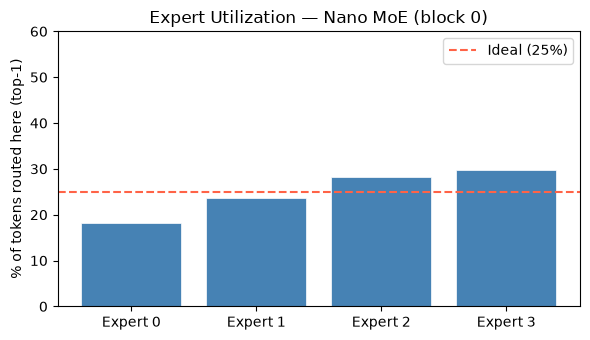

Saved assets/10_expert_utilization.png


In [13]:
fig, ax = plt.subplots(figsize=(6, 3.5))
x_pos = range(N_EXPERTS)
bars  = ax.bar(x_pos, utilization.numpy() * 100, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axhline(100 / N_EXPERTS, color="tomato", linestyle="--", linewidth=1.5, label=f"Ideal ({100/N_EXPERTS:.0f}%)")
ax.set_xticks(list(x_pos))
ax.set_xticklabels([f"Expert {e}" for e in x_pos])
ax.set_ylabel("% of tokens routed here (top-1)")
ax.set_title("Expert Utilization — Nano MoE (block 0)")
ax.set_ylim(0, 60)
ax.legend()
fig.tight_layout()
fig.savefig("assets/10_expert_utilization.png", dpi=150)
plt.show()
print("Saved assets/10_expert_utilization.png")

---
## Part 9 — Active vs Total Parameters

One of the most appealing properties of MoE is that you can scale **capacity**
(total parameters) independently of **compute** (active parameters per token).

In [14]:
print("=" * 55)
print("  Parameter accounting for nano MoEGPT")
print("=" * 55)
print(f"  Total parameters (all experts stored) : {total_params:>10,}")
print(f"  Active parameters per token (top-{TOP_K}) : {active_params:>10,}")
print(f"  Sparsity ratio                         : {active_params/total_params:>9.1%}")
print("=" * 55)
print()
print(
    "Key insight: a dense model with the same *compute* per token would\n"
    f"have roughly {active_params:,} parameters. Our MoE has {total_params:,}\n"
    f"— {total_params/active_params:.1f}× more capacity for the same FLOPs.\n\n"
    "At the frontier, Mixtral 8×7B has ~46 B total parameters but only\n"
    "~12 B active per token — giving the compute cost of a 12B dense model\n"
    "with the quality of a much larger one."
)

  Parameter accounting for nano MoEGPT
  Total parameters (all experts stored) :  1,927,680
  Active parameters per token (top-2) :  1,042,944
  Sparsity ratio                         :     54.1%

Key insight: a dense model with the same *compute* per token would
have roughly 1,042,944 parameters. Our MoE has 1,927,680
— 1.8× more capacity for the same FLOPs.

At the frontier, Mixtral 8×7B has ~46 B total parameters but only
~12 B active per token — giving the compute cost of a 12B dense model
with the quality of a much larger one.


---
## Part 10 — Loss Curve

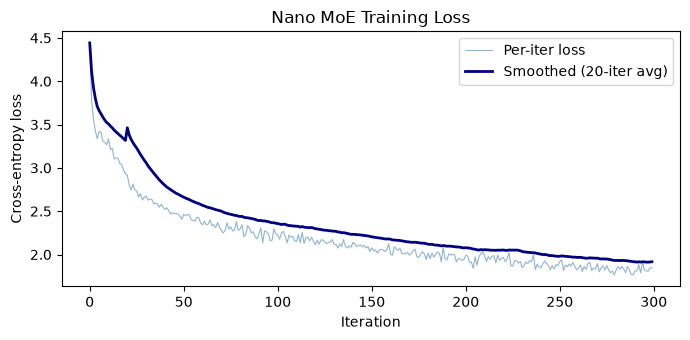

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(losses, color="steelblue", linewidth=0.8, alpha=0.6, label="Per-iter loss")
# Smooth with a rolling mean.
window = 20
if len(losses) >= window:
    smooth = [sum(losses[max(0, i-window):i+1]) / min(i+1, window) for i in range(len(losses))]
    ax.plot(smooth, color="navy", linewidth=2, label=f"Smoothed ({window}-iter avg)")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Nano MoE Training Loss")
ax.legend()
fig.tight_layout()
plt.show()

---
## Course Recap

Congratulations — you have completed the full curriculum!

Here is every major idea, in the order we built it:

| Notebook | Topic | Key ideas |
|---|---|---|
| 01 | Data & Bag-of-Words | Tokenisation, vocabulary, loss baseline |
| 02 | Embeddings | Dense vectors, cosine similarity, semantic geometry |
| 03 | Attention | Scaled dot-product attention, causal masking |
| 04 | Modern Components | RMSNorm, SwiGLU, RoPE, GQA |
| 05 | Assembling the Model | Full GPT from scratch |
| 06 | Training | AdamW, gradient clipping, checkpointing |
| 07 | Eval & Generation | Perplexity, sampling strategies, KV-cache |
| 08 | Tuning | LR warmup + cosine schedule, hyperparameter sweeps |
| 09 | BPE Tokenizer | Byte-Pair Encoding from scratch, tiktoken |
| **10** | **MoE (this notebook)** | **Experts, top-k routing, load balancing, sparse scaling** |

### Where to go next

- **Fine-tuning & RLHF** — supervised instruction tuning (SFT) + reinforcement
  learning from human feedback to turn a raw language model into an assistant.
- **Quantisation** — INT8 / INT4 / GPTQ to fit large models in less memory.
- **Speculative decoding** — use a small draft model to propose tokens, verified
  by the large model, for faster inference.
- **Flash Attention** — IO-aware rewrite of attention that is 2–4× faster on
  modern GPUs.
- **Scaling laws** — Chinchilla, compute-optimal training, emergent abilities.
- **Production serving** — vLLM, TGI, continuous batching, paged KV-caches.

You now have all the conceptual building blocks to read any modern LLM paper
and understand what every section is doing. Happy training!